# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [1]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

2025-07-07 14:44:43.138229: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
# Inspect the shapes of the datasets
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

print(f'Before one-hot encoding: {y_train[0]}')
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)
print(f'After one-hot encoding: {y_train[0]}')



X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)
Before one-hot encoding: 9
After one-hot encoding: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


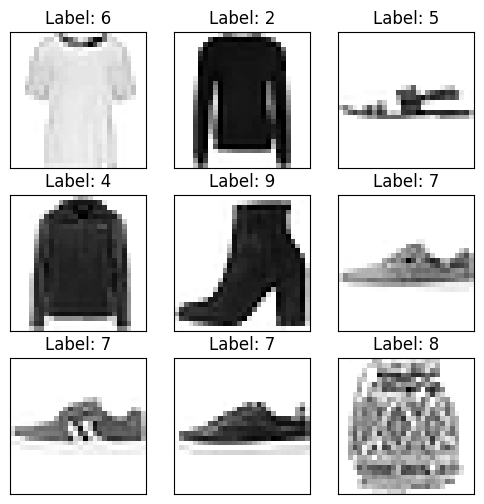

In [11]:
import matplotlib.pyplot as plt
import numpy as np
# Verify the data looks as expected

# Selecting 9 random indices
random_indices = np.random.choice(len(X_train), 9, replace=False)

# Creating a 3x3 grid plot
fig, axes = plt.subplots(3, 3, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[random_indices[i]], cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f"Label: {np.argmax(y_train[random_indices[i]])}")

    # Removing axis labels
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**Your answer here**

yes the data does look as expected. They are low resolution images with labels. The labels of the data set seem to labels different clothing categories. No issues that I notice so far.

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

# Create a simple linear regression model
model = Sequential()

model.add(Flatten(input_shape=(28, 28)))

# Output layer
model.add(Dense(10)) 
model.summary()


# Compile the model using `model.compile()`
model.compile(
            loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy']
)


# Train the model with `model.fit()`

model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)


# Evaluate the model with `model.evaluate()`
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

/Applications/miniconda3/envs/dsi_env2/lib/python3.9/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2206 - loss: 9.8262 - val_accuracy: 0.2887 - val_loss: 9.4958
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2849 - loss: 8.9218 - val_accuracy: 0.3017 - val_loss: 9.8429
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2938 - loss: 8.0562 - val_accuracy: 0.2801 - val_loss: 8.0963
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2716 - loss: 9.1039 - val_accuracy: 0.2810 - val_loss: 9.9255
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3066 - loss: 9.0864 - val_accuracy: 0.3135 - val_loss: 9.5897
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3077 - loss: 9.7089
Loss:     9.63
Accuracy: 31.26%


Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**Your answer here**

The performance is very low. I did expect this to happen since we are only using a simple linear regression with one Dense Layer. Adding more dense layers can help the model accuracy. 

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [ ]:
from keras.layers import Conv2D

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# simple CNN model
model = Sequential()

# Convolutional layer
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))

#flatten the output to progress from convolution to connected layer.
model.add(Flatten())

# fully connected layer
model.add(Dense(64, activation='relu')) 

# Output layer
model.add(Dense(10, activation='softmax')) 

model.summary()



#compile the model:
model.compile(
            loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy']
)


# Train the model
model.fit(
    X_train, 
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)



# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

/Applications/miniconda3/envs/dsi_env2/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     1,384,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,385,482 (5.29 MB)

 Trainable params: 1,385,482 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.8106 - loss: 0.5325 - val_accuracy: 0.8892 - val_loss: 0.3115
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9003 - loss: 0.2719 - val_accuracy: 0.9002 - val_loss: 0.2777
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9221 - loss: 0.2146 - val_accuracy: 0.8989 - val_loss: 0.2786
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.9313 - loss: 0.1875 - val_accuracy: 0.8987 - val_loss: 0.2889
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.9434 - loss: 0.1509 - val_accuracy: 0.9038 - val_loss: 0.2961
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8970 - loss: 0.3181
Loss:     0.31
Accuracy: 89.76%


Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

The CNN model performed better by 58.5%. This is because of the added Convoluted layer which will get data from local patterns on an image, then the fully connected layer will combine this data and will make more accurate decisions.

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [ ]:
# A. Test Hyperparameters
#Testing the number of filters in the convoluted layer.

filters_numbers = [32, 64, 128]
results = []

# performing a for loop for each filter number.
# Convolutional layer

for filters in filters_numbers:
    model = Sequential()
    model.add(Conv2D(filters, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))

    #flatten the output to progress from convolution to connected layer.
    model.add(Flatten())

    # fully connected layer
    model.add(Dense(64, activation='relu')) 

    # Output layer
    model.add(Dense(10, activation='softmax')) 


    #compile the model:
    model.compile(
                loss='categorical_crossentropy',
                optimizer='adam',
                metrics=['accuracy']
    )


    # Train the model
    model.fit(
        X_train, 
        y_train,
        epochs=5,
        batch_size=32,
        validation_split=0.2
    )

    #store results in results list.
    loss, accuracy = model.evaluate(X_test, y_test)
    results.append({'filters': filters, 'loss': loss, 'accuracy': accuracy})

for res in results:
    print(f"Filters: {res['filters']}, Loss: {res['loss']}, Accuracy: {res['accuracy']*100}%")



/Applications/miniconda3/envs/dsi_env2/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.8177 - loss: 0.5233 - val_accuracy: 0.8873 - val_loss: 0.3085
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9041 - loss: 0.2660 - val_accuracy: 0.8897 - val_loss: 0.3005
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9254 - loss: 0.2026 - val_accuracy: 0.9034 - val_loss: 0.2760
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9402 - loss: 0.1623 - val_accuracy: 0.9042 - val_loss: 0.2724
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9521 - loss: 0.1297 - val_accuracy: 0.9058 - val_loss: 0.2911
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8997 - loss: 0.3110
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.8056 - loss: 0.5437 - val_accuracy: 0.8862 - val_loss: 0.3119
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.9026 - loss: 0.2648 - val_accuracy: 0.8989 - val_loss: 0.2778
Epoch 3/

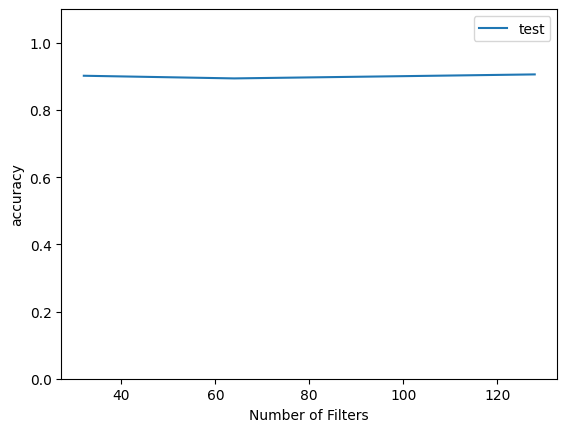

In [24]:
import matplotlib.pyplot as plt

filter_values = [r['filters'] for r in results]
acc_values = [r['accuracy'] for r in results]

plt.plot(filter_values, acc_values, label='test')
plt.ylim(0, 1.1)
plt.ylabel("accuracy")
plt.xlabel("Number of Filters")
plt.legend(loc='best')
plt.show()

In [25]:
# B. Test presence or absence of regularization
from keras.layers import Dropout

dropout_presence = [True, False]
dropout_results = []

# performing a for loop for a dropout and no dropout presence.
for dropout in dropout_presence:
    model = Sequential()
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))

    #flatten the output to progress from convolution to connected layer.
    model.add(Flatten())

    # fully connected layer
    model.add(Dense(64, activation='relu')) 

    #if dropout is true, then drop 50% of neurons for training.
    if dropout:
        model.add(Dropout(0.5))

    # Output layer
    model.add(Dense(10, activation='softmax')) 


    #compile the model:
    model.compile(
                loss='categorical_crossentropy',
                optimizer='adam',
                metrics=['accuracy']
    )

    # Train the model
    model.fit(
        X_train, 
        y_train,
        epochs=5,
        batch_size=32,
        validation_split=0.2
    )

    #store results in dropout results list.
    loss, accuracy = model.evaluate(X_test, y_test)
    dropout_results.append({'dropout': dropout, 'loss': loss, 'accuracy': accuracy})

for res in dropout_results:
    print(f"Dropout: {res['dropout']}, Loss: {res['loss']}, Accuracy: {res['accuracy']*100}%")


/Applications/miniconda3/envs/dsi_env2/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.7045 - loss: 0.8371 - val_accuracy: 0.8694 - val_loss: 0.3629
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.8362 - loss: 0.4585 - val_accuracy: 0.8733 - val_loss: 0.3425
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8571 - loss: 0.3927 - val_accuracy: 0.8893 - val_loss: 0.2999
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.8711 - loss: 0.3561 - val_accuracy: 0.8967 - val_loss: 0.2912
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.8783 - loss: 0.3280 - val_accuracy: 0.8989 - val_loss: 0.2837
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8911 - loss: 0.2994
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.8137 - loss: 0.5319 - val_accuracy: 0.8836 - val_loss: 0.3202
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.8975 - loss: 0.2760 - val_accuracy: 0.8879 - val_loss: 0.3170
Epoch 3/

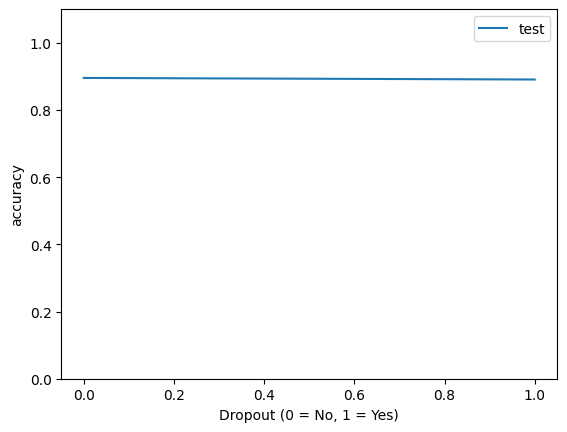

In [26]:
dropout_values = [int(r['dropout']) for r in dropout_results]  # 1 = with dropout, 0 = no dropout
acc_values = [r['accuracy'] for r in dropout_results]

plt.plot(dropout_values, acc_values, label='test')
plt.ylim(0, 1.1)
plt.ylabel("accuracy")
plt.xlabel("Dropout (0 = No, 1 = Yes)")
plt.legend(loc='best')
plt.show()

Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

The best performing hyperparameter tested in terms of its accuracy used 128 filters, reaching an accuracy score of 90.5%. The 32 filter model came in second with 90.1%. Even though the 128 filter model had a slightly better accuracy score, the loss score of the 32 filter was lower, meaning we can be more confident in our predictions. Therefore, I think the 32 filter performed the best overall. This was counterintuitive for me since I thought increasing the number of filters would have an overall improvement on the accuracy and loss scores, but this was not the case. There seems to be a diminishing return with the increase in filter numbers.

For the regularization technique, not having a dropout in the model performed better vs having a dropout (89.52% vs 89.05%). This is a slight improvement with accuracy. Dropout is not always necessary, possibly because this is a simpler model. 

Overall, using the 32 filters and no dropout combination yielded the best performance for the model. 



# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [27]:
final_model = Sequential()
final_model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))

    #flatten the output to progress from convolution to connected layer.
final_model.add(Flatten())
    # fully connected layer
final_model.add(Dense(64, activation='relu')) 
    # Output layer
final_model.add(Dense(10, activation='softmax')) 

    #compile the model:
final_model.compile(
                loss='categorical_crossentropy',
                optimizer='adam',
                metrics=['accuracy']
    )

    # Train the model
final_model.fit(
        X_train, 
        y_train,
        epochs=5,
        batch_size=32,
        validation_split=0.2
    )

final_loss, final_accuracy = final_model.evaluate(X_test, y_test)
print({"final_loss": final_loss, "accuracy":final_accuracy*100})

/Applications/miniconda3/envs/dsi_env2/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.7947 - loss: 0.5756 - val_accuracy: 0.8827 - val_loss: 0.3292
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.8993 - loss: 0.2807 - val_accuracy: 0.8954 - val_loss: 0.2895
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9187 - loss: 0.2206 - val_accuracy: 0.8989 - val_loss: 0.2819
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9354 - loss: 0.1791 - val_accuracy: 0.9060 - val_loss: 0.2752
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9471 - loss: 0.1483 - val_accuracy: 0.9043 - val_loss: 0.2915
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8962 - loss: 0.3163
{'final_loss': 0.3091837763786316, 'accuracy': 89.71999883651733}


Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

The final version is much better in accuracy and minizing the loss as compared to the baseline. The final version is performing as expected with 32 filters and no dropout. I believe that since this might be a simpler dataset, there was no need to overcomplicated the model, therefore, the simpler models/hyperparameters/regularization works best. 

to further improve the model's performance, I would add more dense layers and try the L2 regularization. I believe more dense layers will make the model more accurate and increase its performance. However, there may also be a platueing effect, as with most models I believe.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 06/07/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-6-ml-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.